In [1]:
# 1) LIBRARIES
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import xgboost as xgb
import joblib

In [5]:
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

In [2]:
# 2) LOAD DATA
df = pd.read_csv("data.csv")
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [6]:
# Build node index
banks = pd.Index(sorted(set(df["From Bank"]).union(set(df["To Bank"]))))
bank2idx = {b: i for i, b in enumerate(banks)}

src = df["From Bank"].map(bank2idx).to_numpy()
dst = df["To Bank"].map(bank2idx).to_numpy()

edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_labels = df["Is Laundering"].astype(int).to_numpy()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19668\2912421024.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


In [7]:
# Node features: identity (one-hot per bank)
num_nodes = len(banks)
x = torch.eye(num_nodes, dtype=torch.float)

In [8]:
# Define a GAT layer
gat = GATv2Conv(in_channels=num_nodes, out_channels=8, heads=1, concat=True)

In [9]:
# Forward pass (no training)
with torch.no_grad():
    z = gat(x, edge_index)  # node embeddings

In [10]:
# Build NetworkX graph for visualization
G = nx.DiGraph()
for i, bank in enumerate(banks):
    G.add_node(i, label=bank)

for s, d, lbl in zip(src, dst, edge_labels):
    G.add_edge(s, d, laundering=lbl)

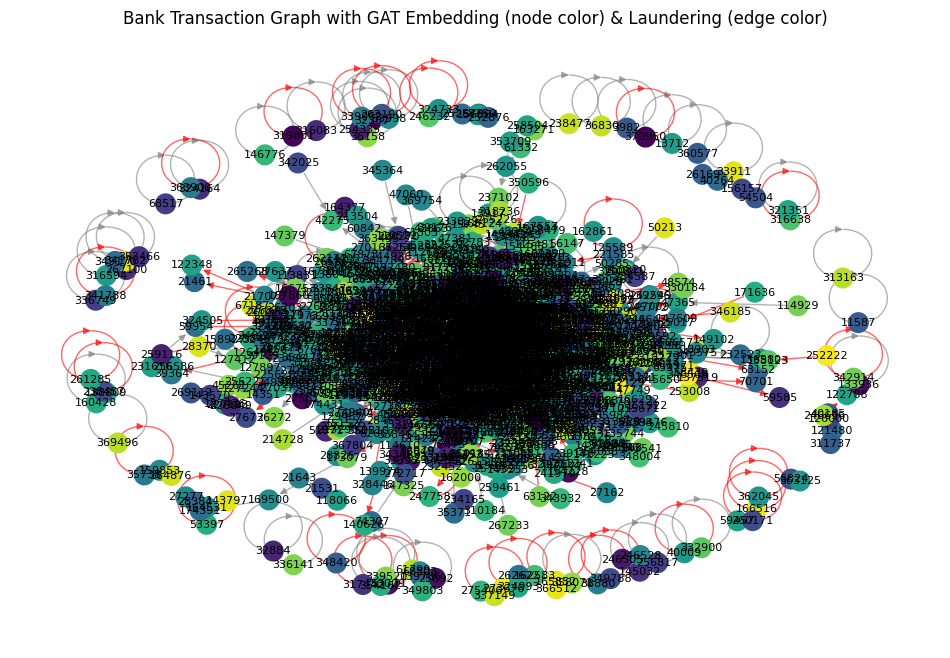

In [11]:
# Node colors from embeddings (project to scalar using first dimension)
node_color = z[:, 0].numpy()
edge_color = ["red" if lbl == 1 else "gray" for lbl in edge_labels]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.3)

nx.draw_networkx_nodes(G, pos, node_color=node_color, cmap=plt.cm.viridis, node_size=200)
nx.draw_networkx_edges(G, pos, edge_color=edge_color, arrows=True, alpha=0.6)
nx.draw_networkx_labels(G, pos, labels={i: banks[i] for i in range(num_nodes)}, font_size=8)

plt.title("Bank Transaction Graph with GAT Embedding (node color) & Laundering (edge color)")
plt.axis("off")
plt.show()

In [3]:
# 3) LABEL ENCODING
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Column '{col}' encoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Column 'Receiving Currency' encoded classes: {'Australian Dollar': 0, 'Bitcoin': 1, 'Brazil Real': 2, 'Canadian Dollar': 3, 'Euro': 4, 'Mexican Peso': 5, 'Ruble': 6, 'Rupee': 7, 'Saudi Riyal': 8, 'Shekel': 9, 'Swiss Franc': 10, 'UK Pound': 11, 'US Dollar': 12, 'Yen': 13, 'Yuan': 14}
Column 'Payment Currency' encoded classes: {'Australian Dollar': 0, 'Bitcoin': 1, 'Brazil Real': 2, 'Canadian Dollar': 3, 'Euro': 4, 'Mexican Peso': 5, 'Ruble': 6, 'Rupee': 7, 'Saudi Riyal': 8, 'Shekel': 9, 'Swiss Franc': 10, 'UK Pound': 11, 'US Dollar': 12, 'Yen': 13, 'Yuan': 14}
Column 'Payment Format' encoded classes: {'ACH': 0, 'Bitcoin': 1, 'Cash': 2, 'Cheque': 3, 'Credit Card': 4, 'Reinvestment': 5, 'Wire': 6}


In [4]:
# 4) FEATURE ENGINEERING
df["Amount Difference"] = (df["Amount Received"] - df["Amount Paid"]).abs()
df["Amount Ratio"] = df["Amount Received"] / (df["Amount Paid"] + 1e-6)
df["Same Currency"] = (df["Receiving Currency"] == df["Payment Currency"]).astype(int)

In [5]:
# Transaction frequency features
from_counts = df["From Bank"].map(df["From Bank"].value_counts())
to_counts   = df["To Bank"].map(df["To Bank"].value_counts())
df["From Tx Count"] = from_counts
df["To Tx Count"]   = to_counts

In [6]:
# 5) DEFINE X & y
X = df.drop(columns=["Is Laundering"])
y = df["Is Laundering"]

In [7]:
# Scale continuous features
num_cols = ["Amount Received", "Amount Paid", "Amount Difference", "Amount Ratio", "From Tx Count", "To Tx Count"]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [8]:
# 6) TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [9]:
# 7) XGBOOST WITH HYPERPARAMETER TUNING
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=(len(y) - sum(y)) / sum(y)  # imbalance handling
)

In [10]:
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [11]:
grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    verbose=2,
    n_jobs=-1
)

In [12]:
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("\nBest Parameters:", grid.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}


e:\Softwares\anaconda3\envs\avr\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:34:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
# 8) EVALUATION
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.9081346423562412
Confusion Matrix:
 [[592 121]
 [ 10 703]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9834    0.8303    0.9004       713
           1     0.8532    0.9860    0.9148       713

    accuracy                         0.9081      1426
   macro avg     0.9183    0.9081    0.9076      1426
weighted avg     0.9183    0.9081    0.9076      1426

ROC-AUC: 0.9474977821228282


In [14]:
# 9) SAVE MODEL + ENCODERS
joblib.dump(best_model, "xgb_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump({"X_columns": X.columns.tolist(), "num_cols": num_cols}, "metadata.pkl")
print("\nModel and encoders saved!")


Model and encoders saved!


In [2]:
import pandas as pd
import joblib

# Load artifacts
model = joblib.load("xgb_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")
scaler = joblib.load("scaler.pkl")
metadata = joblib.load("metadata.pkl")   # contains feature names, num_cols

X_columns = metadata["X_columns"]
num_cols  = metadata["num_cols"]

def predict_custom(sample: dict):
    """
    Make prediction on a single new transaction.

    sample = {
        "From Bank": int,
        "To Bank": int,
        "Amount Received": float,
        "Receiving Currency": "US Dollar",
        "Amount Paid": float,
        "Payment Currency": "US Dollar",
        "Payment Format": "ACH"
    }
    """
    # Encode categorical fields
    sample_enc = sample.copy()
    for col, le in label_encoders.items():
        if col in sample_enc:
            sample_enc[col] = int(le.transform([sample_enc[col]])[0])

    # Feature engineering
    sample_enc["Amount Difference"] = abs(sample_enc["Amount Received"] - sample_enc["Amount Paid"])
    sample_enc["Amount Ratio"] = sample_enc["Amount Received"] / (sample_enc["Amount Paid"] + 1e-6)
    sample_enc["Same Currency"] = int(sample_enc["Receiving Currency"] == sample_enc["Payment Currency"])
    # Default to 1 if unseen bank
    sample_enc["From Tx Count"] = 1
    sample_enc["To Tx Count"] = 1

    # Build dataframe with correct column order
    df_in = pd.DataFrame([sample_enc], columns=X_columns)

    # Scale numeric cols
    df_in[num_cols] = scaler.transform(df_in[num_cols])

    # Prediction
    prob = model.predict_proba(df_in)[0, 1]
    label = "Laundering" if prob >= 0.5 else "Not Laundering"

    return {"probability": float(prob), "prediction": int(prob >= 0.5), "label": label}

# Example usage
if __name__ == "__main__":
    sample_input = {
        "From Bank": 135558,
        "To Bank": 16,
        "Amount Received": 24057.68,
        "Receiving Currency": "Canadian Dollar",
        "Amount Paid": 24057.68,
        "Payment Currency": "Canadian Dollar",
        "Payment Format": "Cash"
    }
    print(predict_custom(sample_input))

{'probability': 0.1387852281332016, 'prediction': 0, 'label': 'Not Laundering'}
